# Part C: Basic SfM via Tomasi-Kanade Factorization

Implementation of the Tomasi-Kanade factorization on clean synthetic data. We evaluate reconstruction quality, and visualize ground truth vs. reconstructed 3D structure.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from src.data_loader import generate_sfm_data
from src.factorization import factorize_tomasi_kanade, center_data
from src.utils import plot_sfm_data, plot_structure_comparison, procrustes_align, reprojection_rmse

## 1. Generate Clean Synthetic Data

In [2]:
# Generate clean data (no noise, no missing, no outliers)
data = generate_sfm_data(num_points=30, num_frames=10, seed=42, point_shape="full_3d")

W = data["measurement_matrix"]  # (2F, P)
S_gt = data["points_3d"]        # (3, P)

print(f"Measurement matrix shape: {W.shape}")
print(f"Ground truth 3D points:   {S_gt.shape}")
print(f"Number of frames: {W.shape[0] // 2}, Number of points: {W.shape[1]}")

Measurement matrix shape: (20, 30)
Ground truth 3D points:   (3, 30)
Number of frames: 10, Number of points: 30


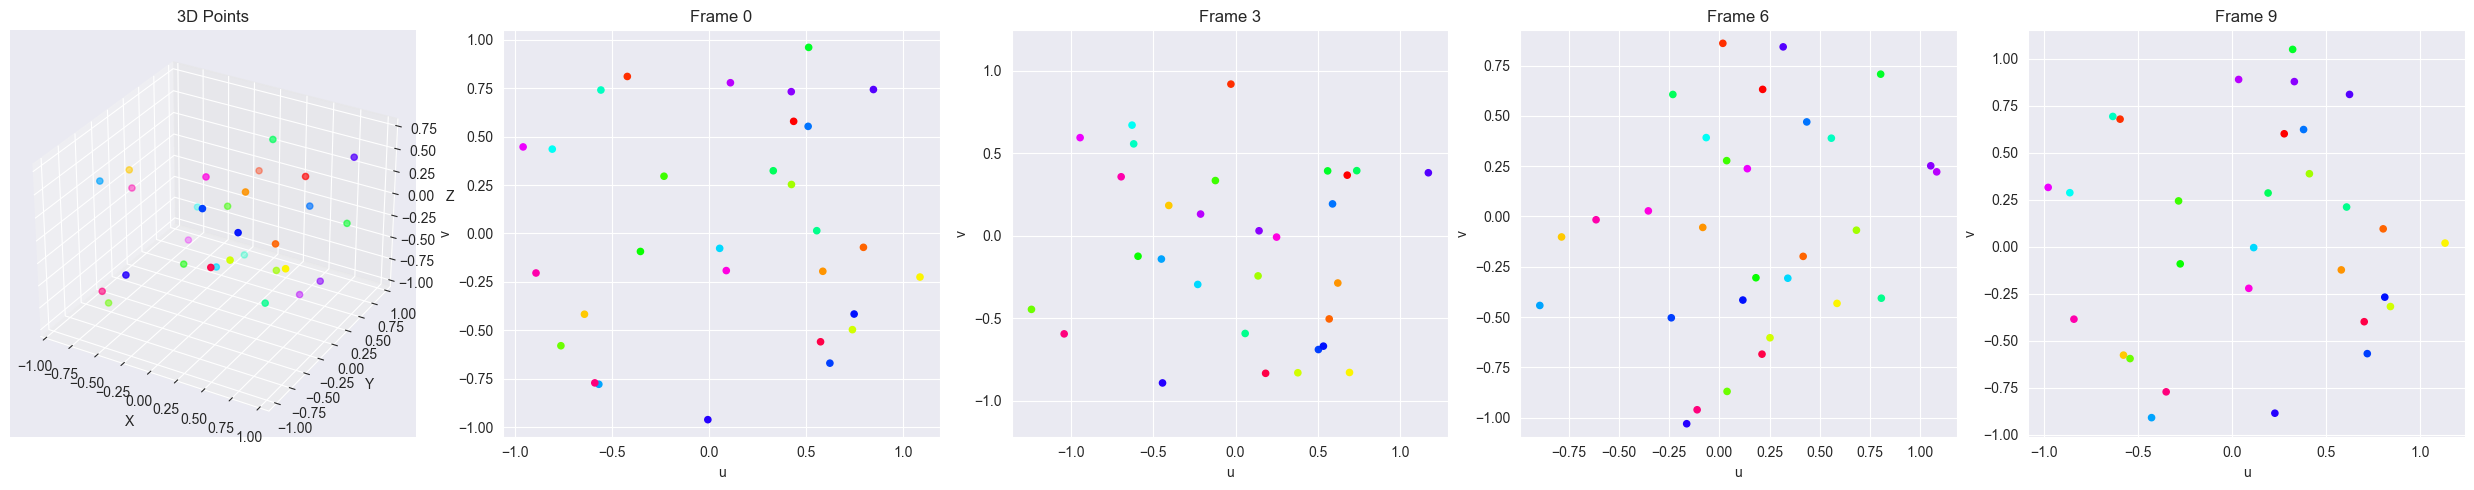

In [3]:
# Visualize the ground truth 3D structure and sample 2D projections
plot_sfm_data(data)

## 2. Singular Value Analysis

Verify the rank-3 property of the centered measurement matrix.

Top 6 singular values:
  σ_1 = 9.480496
  σ_2 = 8.216824
  σ_3 = 4.256673 <-- rank-3 cutoff
  σ_4 = 0.000000
  σ_5 = 0.000000
  σ_6 = 0.000000


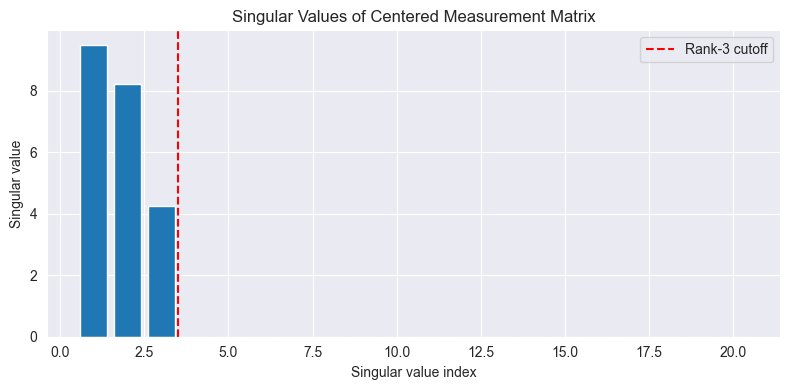

In [4]:
# Center and inspect singular values
W_centered, translations = center_data(W)
singular_values = np.linalg.svd(W_centered, compute_uv=False)

print("Top 6 singular values:")
for i, sv in enumerate(singular_values[:6]):
    marker = " <-- rank-3 cutoff" if i == 2 else ""
    print(f"  σ_{i+1} = {sv:.6f}{marker}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, len(singular_values) + 1), singular_values)
ax.axvline(x=3.5, color="red", linestyle="--", label="Rank-3 cutoff")
ax.set_xlabel("Singular value index")
ax.set_ylabel("Singular value")
ax.set_title("Singular Values of Centered Measurement Matrix")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Factorization and Evaluation

Run the Tomasi-Kanade factorization and evaluate with two metrics:
- **Reprojection RMSE**: How well does $M \cdot S + t$ reproduce the original 2D measurements?
- **3D Structure RMSE (Procrustes)**: After aligning the recovered structure to ground truth via Procrustes (optimal rotation + uniform scale), how close are the 3D points?

On clean noiseless data the reprojection error should be near machine precision, since the centered measurement matrix is exactly rank 3.
Since we do not enforce metric constraints, the 3D structure will be correct up to an affine transformation, which is why we see a nonzero 3D structure error even after Procrustes alignment.

In [5]:
# --- Basic factorization (no metric enforcement) ---
motion, structure, trans = factorize_tomasi_kanade(W)

print(f"Motion matrix shape:    {motion.shape}   (2F × 3)")
print(f"Structure matrix shape: {structure.shape}   (3 × P)")

# Reprojection error: M·S + t  vs  original measurements
reproj_err = reprojection_rmse(W, motion, structure, trans)
print(f"\nReprojection RMSE: {reproj_err:.2e}")

# 3D structure error after Procrustes alignment
S_aligned, struct_err = procrustes_align(structure, S_gt)
print(f"3D Structure RMSE (Procrustes): {struct_err:.2e}")

Motion matrix shape:    (20, 3)   (2F × 3)
Structure matrix shape: (3, 30)   (3 × P)

Reprojection RMSE: 8.11e-16
3D Structure RMSE (Procrustes): 7.04e-02


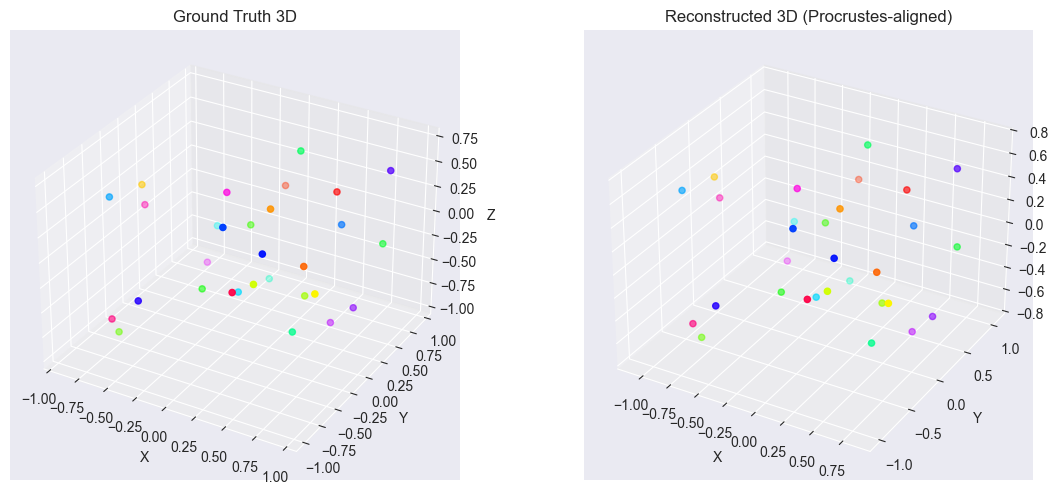

In [6]:
# Side-by-side 3D comparison: Ground Truth vs Reconstructed (Procrustes-aligned)
plot_structure_comparison(S_gt, S_aligned,
                          title_gt="Ground Truth 3D",
                          title_est="Reconstructed 3D (Procrustes-aligned)")

## 4. Error vs Number of Frames and Points

Reporting of error as a function of frames (or points). We sweep both axes on clean data to establish a baseline.

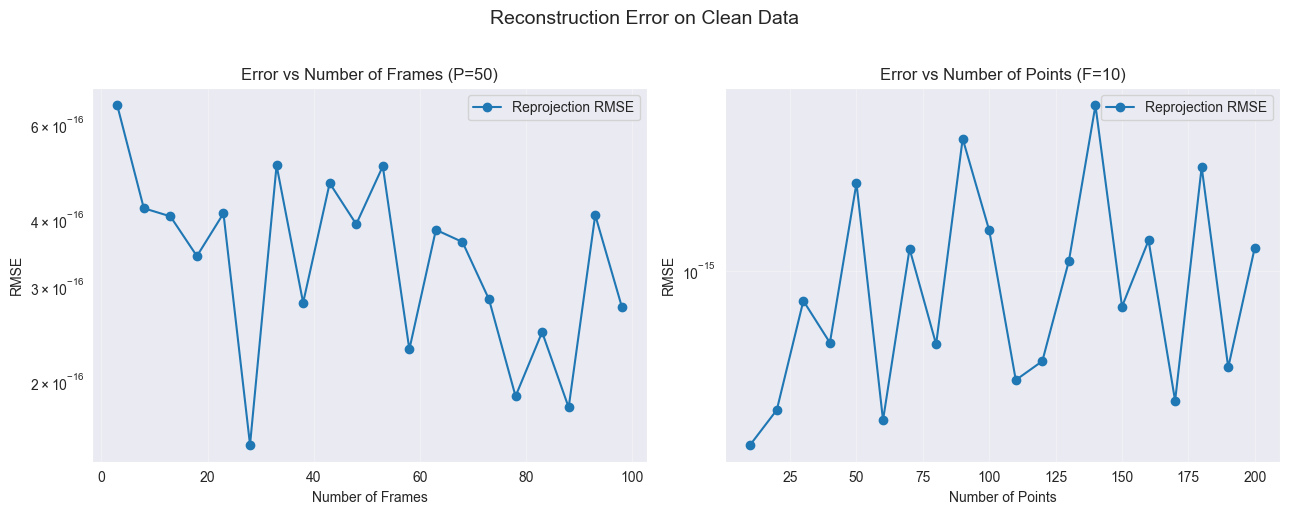

In [7]:
# Error as a function of number of frames (fixed P=50)
frame_counts = list(range(3, 101, 5))
reproj_by_frames = []

for nf in frame_counts:
    d = generate_sfm_data(num_points=50, num_frames=nf, seed=42, point_shape='near_planar')
    M, S, t = factorize_tomasi_kanade(d["measurement_matrix"])
    reproj_by_frames.append(reprojection_rmse(d["measurement_matrix"], M, S, t))

# Error as a function of number of points (fixed F=10)
point_counts = list(range(10,201,10))
reproj_by_points = []

for np_ in point_counts:
    d = generate_sfm_data(num_points=np_, num_frames=10, seed=42)
    M, S, t = factorize_tomasi_kanade(d["measurement_matrix"])
    reproj_by_points.append(reprojection_rmse(d["measurement_matrix"], M, S, t))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(frame_counts, reproj_by_frames, "o-", label="Reprojection RMSE")
axes[0].set_xlabel("Number of Frames")
axes[0].set_ylabel("RMSE")
axes[0].set_title("Error vs Number of Frames (P=50)")
axes[0].legend()
axes[0].set_yscale("log")
axes[0].grid(True, alpha=0.3)

axes[1].plot(point_counts, reproj_by_points, "o-", label="Reprojection RMSE")
axes[1].set_xlabel("Number of Points")
axes[1].set_ylabel("RMSE")
axes[1].set_title("Error vs Number of Points (F=10)")
axes[1].legend()
axes[1].set_yscale("log")
axes[1].grid(True, alpha=0.3)

fig.suptitle("Reconstruction Error on Clean Data", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()